<a id='notebook-top'></a>

# Fibrils in Hα Chromospheric Line Width 
---
This notebook shows the consistency between the CHASE Hα chromospheric line width and the presence of dark fibrils in DKIST/VBI Hβ.

Note: The internal hyperlink only works on [GitHub Pages](https://yjzhu-solar.github.io/DKIST_SolO_Fibril/ipynb_html/vbi_chase_line_width.html) or [nbviewer](https://nbviewer.org/github/yjzhu-solar/DKIST_SolO_Fibril/blob/master/ipynb/ms_plot/vbi_chase_line_width.ipynb). Do not click when viewing the notebook on GitHub.

## Import libraries and plotting configurations

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.patches import Polygon
import sunpy
import sunpy.map
from sunpy.coordinates import get_earth, propagate_with_solar_surface
import dkist 
import dask.array as da
import h5py
from astropy.time import Time
from astropy.io import ascii, fits
from astropy.wcs import WCS
from astropy.visualization import (ImageNormalize, 
                    SqrtStretch, AsinhStretch,
                    ZScaleInterval)
import astropy.units as u
from ndcube import NDCube
from ndcube.wcs.tools import unwrap_wcs_to_fitswcs
from fancy_colorbar import wcs_scalebar, plot_colorbar
from glob import glob 
from IPython.display import HTML

## Load preprocessed data

### DKIST/VBI data

In [2]:
file_Hbeta_pr = h5py.File("../../data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_pr.hdf5")
Hbeta_pr_set = file_Hbeta_pr["vbi_img"]
Hbeta_pr_da = da.from_array(Hbeta_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
Hbeta_date_obs = Time(ascii.read("../../data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_date_avg.txt")["DATE-AVG"])

In [3]:
dkist_vbi_target_header = fits.getheader("../../data/pid_1_123_aux/plot_ready/dkist_target_wcs_header_before_crop.fits",
                                        ignore_missing_simple=True)

dkist_vbi_target_data = np.zeros((4096,4096))

dkist_vbi_target_cube = NDCube(dkist_vbi_target_data,WCS(dkist_vbi_target_header, naxis=2))
dkist_vbi_target_cube_crop = dkist_vbi_target_cube[128:-128,128:-128]
dkist_vbi_target_cube_crop_rebin = dkist_vbi_target_cube_crop.rebin((64,64)) # ~ 0.65 arcsec/pix, enough to cover CHASE ~ 1. arcsec/pix

target_wcs = dkist_vbi_target_cube_crop.wcs
target_wcs = unwrap_wcs_to_fitswcs(target_wcs)[0]
target_wcs_rebin = dkist_vbi_target_cube_crop_rebin.wcs
target_wcs_rebin = unwrap_wcs_to_fitswcs(target_wcs_rebin)[0]


Set MJD-BEG to 59876.791095 from DATE-BEG.
Set MJD-AVG to 59876.791095 from DATE-AVG.
Set MJD-END to 59876.791095 from DATE-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [4]:
target_wcs.wcs.cdelt*3600*64

array([0.65017509, 0.65017509])

### Load and reproject CHASE Hα line width data

In [5]:
chase_dummpy_map = sunpy.map.Map("../../data/pid_1_123_aux/CHASE/chase_line_width_npy/chase_line_width_wcs_shifted.fits")
chase_line_width_cube = np.load("../../data/pid_1_123_aux/CHASE/chase_line_width_npy/chase_line_width_shifted.npy")

In [6]:
chase_files = sorted(glob("../../data/pid_1_123_aux/CHASE/RSM*.fits"))
chase_dateobs = []
for chase_file in chase_files:
    chase_dateobs.append(Time(fits.getheader(chase_file, ext=1)["STR_TIME"]))

chase_dateobs = Time(chase_dateobs) + 9.6*u.s # roungh estimation of the scan step time 

In [7]:
vbi_indices = []
for chase_dateobs_ in chase_dateobs:
    vbi_indices.append(np.argmin(np.abs(Hbeta_date_obs - chase_dateobs_)))

In [8]:
chase_line_width_cube.shape

(125, 125, 11)

In [9]:
chase_line_width_maps_reproj = []

with propagate_with_solar_surface():
    for ii in range(len(chase_files)):
        chase_map_ = sunpy.map.Map(chase_line_width_cube[:,:,ii], chase_dummpy_map.wcs)
        chase_map_.meta["rsun_ref"] = 695700000.0
        chase_line_width_maps_reproj.append(chase_map_.reproject_to(target_wcs_rebin,algorithm="adaptive"))


INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Miss

(array([113., 158., 209., 337., 421., 335., 772., 842., 379.,  34.]),
 array([0.92238762, 0.96021744, 0.99804726, 1.03587709, 1.07370691,
        1.11153673, 1.14936655, 1.18719637, 1.22502619, 1.26285601,
        1.30068583]),
 <BarContainer object of 10 artists>)

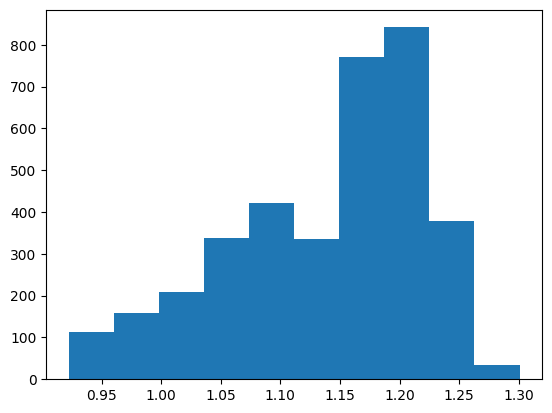

In [10]:
plt.hist(chase_line_width_maps_reproj[0].data.flatten())

In [11]:
Hbeta_pr_da.shape

(282, 3840, 3840)

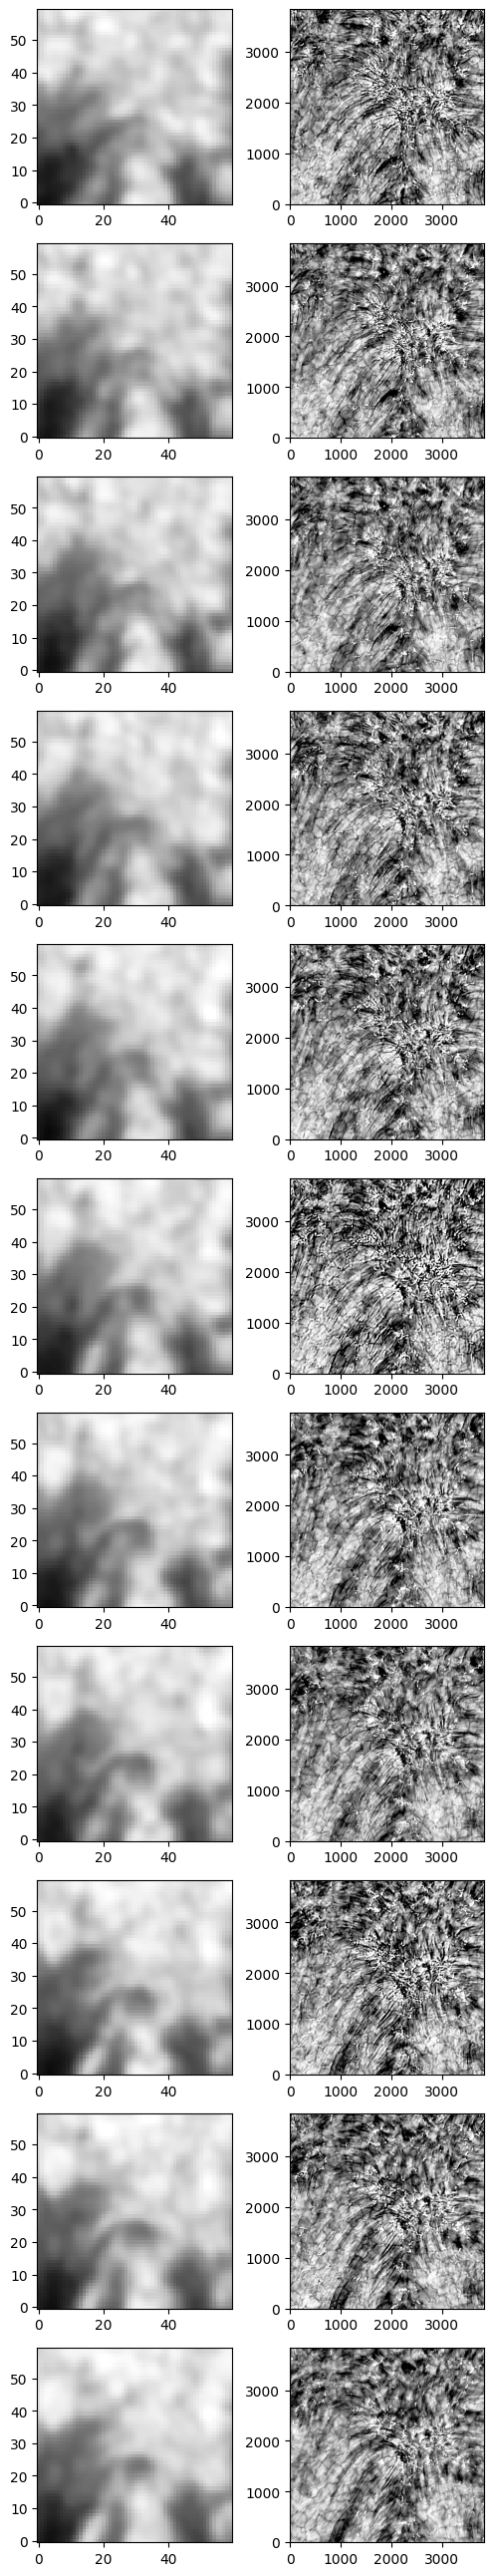

In [12]:
fig, axes = plt.subplots(11,2,figsize=(6,33))

for ii in range(11):
    axes[ii,0].imshow(chase_line_width_maps_reproj[ii].data,vmin=0.9, vmax=1.3,
    origin="lower", interpolation="none", cmap="Greys_r")

    axes[ii,1].imshow(Hbeta_pr_da[vbi_indices[ii],:,:],vmin=0., vmax=1.,
    origin="lower", cmap="Greys_r")

In [13]:
selected_index = [1, 3, 9, 10]

In [14]:
ms_style_dict = {'text.usetex': True, 'font.family': 'serif', 'axes.linewidth': 1.2,
                 'xtick.major.width': 1.2, 'xtick.major.size': 4,
                 'ytick.major.width': 1.2, 'ytick.major.size': 4,
                 'xtick.minor.width': 1.2, 'xtick.minor.size': 2,
                 'ytick.minor.width': 1.2, 'ytick.minor.size': 2,
                 'xtick.direction': 'in', 'ytick.direction': 'in',
                 'text.latex.preamble': r'\usepackage[T1]{fontenc}'
                 r'\usepackage{amsmath}' r'\usepackage{siunitx}'
                 r'\sisetup{detect-all=True}' r'\usepackage{fixltx2e}'}

In [15]:
w_space = 0.0
h_space = 0.0
left_margin = 0.15
right_margin = 0.
top_margin = 0.1
bottom_margin = 0.1
fig_size_scale = 3
fig_x = (left_margin + 2 + w_space + right_margin) 
fig_y = (top_margin + 4 + h_space*3 + bottom_margin)

## Figure 7
---
Comparison between chromospheric H$\alpha$ line widths measured by CHASE/HIS (left) and DKIST/VBI H$\beta$ images (right). The cyan arrows highlight potential correspondences between increases in H$\alpha$ line widths and dark fibril clusters in broadband H$\beta$ imaging. 

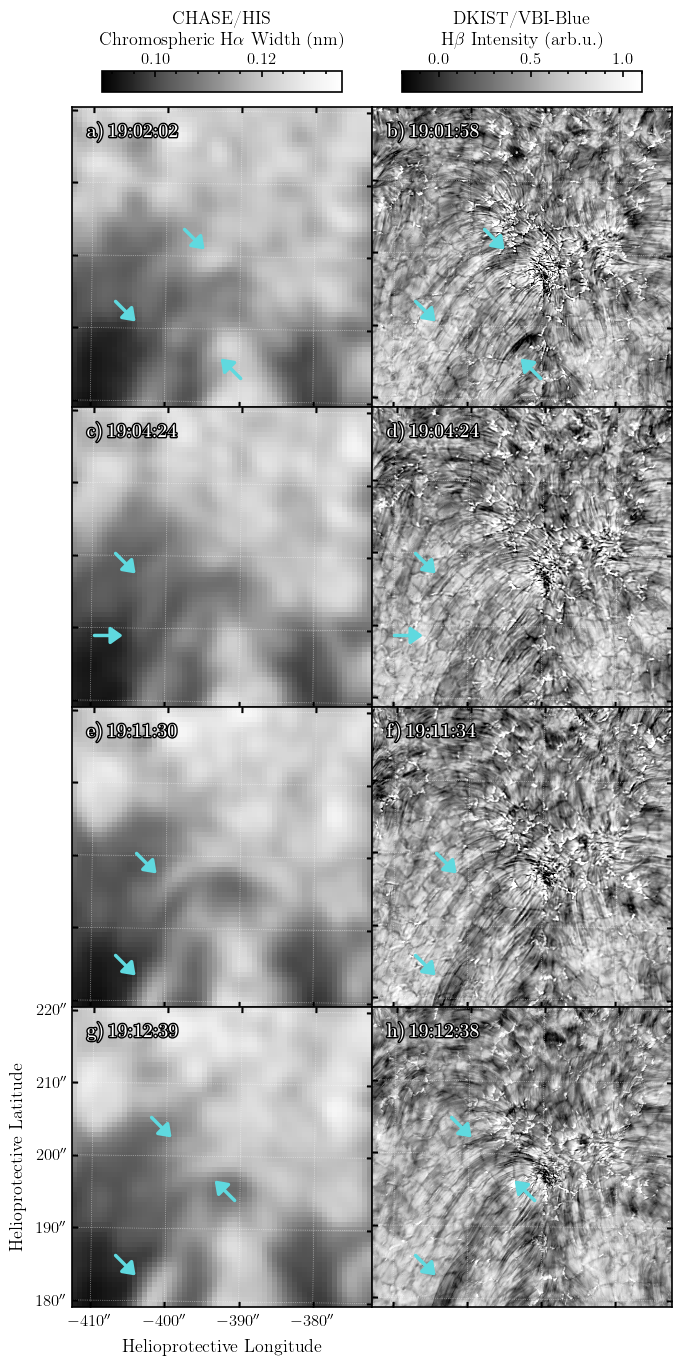

In [16]:
display(HTML('<a href="#notebook-top">Go to top</a>'))
display(HTML('<a id="figure-6"></a>'))

with plt.rc_context(ms_style_dict):
    fig = plt.figure(figsize=(fig_x*fig_size_scale, fig_y*fig_size_scale))
    fig.subplots_adjust(wspace=w_space, hspace=h_space, right=1-right_margin,
    left=left_margin, top=1-top_margin, bottom=bottom_margin,)

    for ii in range(4):
        ax_chase = fig.add_axes([left_margin/fig_x, 1 - (top_margin + ii + (ii-1)*h_space)/fig_y,
        1/fig_x, 1/fig_y], projection=target_wcs_rebin)
        
        im_chase = ax_chase.imshow(chase_line_width_maps_reproj[selected_index[ii]].data/10,vmin=0.09, vmax=0.135,
        origin="lower", interpolation="none", cmap="Greys_r", rasterized=True)

        ax_vbi = fig.add_axes([(left_margin + 1 + w_space)/fig_x, 1 - (top_margin + ii + (ii-1)*h_space)/fig_y,
        1/fig_x, 1/fig_y], projection=target_wcs)

        im_vbi = ax_vbi.imshow(Hbeta_pr_da[vbi_indices[selected_index[ii]],:,:],vmin=-0.2, vmax=1.1,
        origin="lower", cmap="Greys_r", interpolation="none", rasterized=True)

        ax_chase.grid(True, color="w", ls=":", lw=0.5, alpha=0.7)
        ax_vbi.grid(True, color="w", ls=":", lw=0.5, alpha=0.7)

        ax_chase.text(0.05, 0.95, 
        r"\textbf{" + chr(ord('a') + ii*2) + r")\," + \
        chase_dateobs[selected_index[ii]].strftime("%H:%M:%S") + "}",
        transform=ax_chase.transAxes, fontsize=14, va="top", ha="left",
        color="w", path_effects=[path_effects.withStroke(linewidth=2, foreground="k")])

        ax_vbi.text(0.05, 0.95,
        r"\textbf{" + chr(ord('a') + ii*2 + 1) + r")\," + \
        Hbeta_date_obs[vbi_indices[selected_index[ii]]].strftime("%H:%M:%S") + "}",
        transform=ax_vbi.transAxes, fontsize=14, va="top", ha="left",
        color="w", path_effects=[path_effects.withStroke(linewidth=2, foreground="k")])

        for ax_ in (ax_chase, ax_vbi):
            if ii == 0:
                ax_.annotate("",
                xy=(0.45, 0.52), xycoords="axes fraction",
                xytext=(0.45-0.08, 0.52+0.08), textcoords="axes fraction",
                arrowprops=dict(arrowstyle="-|>, head_length={:.3f}, head_width={:.3f}".format(0.7, 0.5),
                color="#5FD9DF", lw=2.5),)

                ax_.annotate("",
                xy=(0.22, 0.28), xycoords="axes fraction",
                xytext=(0.22-0.08, 0.28+0.08), textcoords="axes fraction",
                arrowprops=dict(arrowstyle="-|>, head_length={:.3f}, head_width={:.3f}".format(0.7, 0.5),
                color="#5FD9DF", lw=2.5),)

                ax_.annotate("",
                xy=(0.49, 0.17), xycoords="axes fraction",
                xytext=(0.49+0.08, 0.17-0.08), textcoords="axes fraction",
                arrowprops=dict(arrowstyle="-|>, head_length={:.3f}, head_width={:.3f}".format(0.7, 0.5),
                color="#5FD9DF", lw=2.5),)
        
            if ii == 1:
                ax_.annotate("",
                xy=(0.22, 0.44), xycoords="axes fraction",
                xytext=(0.22-0.08, 0.44+0.08), textcoords="axes fraction",
                arrowprops=dict(arrowstyle="-|>, head_length={:.3f}, head_width={:.3f}".format(0.7, 0.5),
                color="#5FD9DF", lw=2.5),)

                ax_.annotate("",
                xy=(0.18, 0.24), xycoords="axes fraction",
                xytext=(0.18-0.08*np.sqrt(2), 0.24), textcoords="axes fraction",
                arrowprops=dict(arrowstyle="-|>, head_length={:.3f}, head_width={:.3f}".format(0.7, 0.5),
                color="#5FD9DF", lw=2.5),)
            
            if ii == 2:
                ax_.annotate("",
                xy=(0.29, 0.44), xycoords="axes fraction",
                xytext=(0.29-0.08, 0.44+0.08), textcoords="axes fraction",
                arrowprops=dict(arrowstyle="-|>, head_length={:.3f}, head_width={:.3f}".format(0.7, 0.5),
                color="#5FD9DF", lw=2.5),)     

                ax_.annotate("",
                xy=(0.22, 0.10), xycoords="axes fraction",
                xytext=(0.22-0.08, 0.10+0.08), textcoords="axes fraction",
                arrowprops=dict(arrowstyle="-|>, head_length={:.3f}, head_width={:.3f}".format(0.7, 0.5),
                color="#5FD9DF", lw=2.5),)  

            if ii == 3:
                ax_.annotate("",
                xy=(0.47, 0.43), xycoords="axes fraction",
                xytext=(0.47+0.08, 0.43-0.08), textcoords="axes fraction",
                arrowprops=dict(arrowstyle="-|>, head_length={:.3f}, head_width={:.3f}".format(0.7, 0.5),
                color="#5FD9DF", lw=2.5),)   

                ax_.annotate("",
                xy=(0.22, 0.10), xycoords="axes fraction",
                xytext=(0.22-0.08, 0.10+0.08), textcoords="axes fraction",
                arrowprops=dict(arrowstyle="-|>, head_length={:.3f}, head_width={:.3f}".format(0.7, 0.5),
                color="#5FD9DF", lw=2.5),)      

                ax_.annotate("",
                xy=(0.34, 0.56), xycoords="axes fraction",
                xytext=(0.34-0.08, 0.56+0.08), textcoords="axes fraction",
                arrowprops=dict(arrowstyle="-|>, head_length={:.3f}, head_width={:.3f}".format(0.7, 0.5),
                color="#5FD9DF", lw=2.5),)                                        

        if ii == 0:
            clb_chase, clb_chase_ax = plot_colorbar(
                im_chase, ax_chase, bbox_to_anchor=(0.1, 1.05, 0.8, 0.07),
                orientation="horizontal",
            )

            clb_vbi, clb_vbi_ax = plot_colorbar(
                im_vbi, ax_vbi, bbox_to_anchor=(0.1, 1.05, 0.8, 0.07),
                orientation="horizontal",
            )

            clb_chase_ax.set_title("CHASE/HIS\n" + \
                r"Chromospheric H$\alpha$ Width (nm)", fontsize=13)
            clb_vbi_ax.set_title("DKIST/VBI-Blue\n" + \
                r"H$\beta$ Intensity (arb.u.)", fontsize=13)

            for clb_ax_ in (clb_chase_ax, clb_vbi_ax):
                # move ticklabels to the top of the colorbar
                clb_ax_.xaxis.set_ticks_position('top')
                clb_ax_.xaxis.set_label_position('top')
                clb_ax_.tick_params(labelsize=12, axis="both")
        
        ax_chase.tick_params(axis="both", labelsize=12)
        ax_vbi.tick_params(axis="both", labelsize=12)

        if ii == 3:
            ax_chase.coords[0].set_axislabel("Helioprotective Longitude", fontsize=13)
            ax_chase.coords[1].set_axislabel("Helioprotective Latitude", fontsize=13)
            ax_vbi.coords[0].set_ticklabel_visible(False)
            ax_vbi.coords[1].set_ticklabel_visible(False)
        else:
            ax_chase.coords[0].set_ticklabel_visible(False)
            ax_chase.coords[1].set_ticklabel_visible(False)
            ax_vbi.coords[0].set_ticklabel_visible(False)
            ax_vbi.coords[1].set_ticklabel_visible(False)
    
    fig.savefig("../../figs/ms_figure/vbi_chase.pdf", dpi=300, bbox_inches="tight")
    fig.savefig("../../figs/ms_figure_png/vbi_chase.png", dpi=300, bbox_inches="tight")
    plt.show()


    # plt.savefig("vbi_chase_line_width.pdf", bbox_inches="tight")    